In [89]:
import pandas as pd

In [90]:
data = pd.read_csv('./data/iris.csv')

In [91]:
data

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [92]:
X = data.drop('Species', axis=1)

In [93]:
y = data['Species']

In [94]:
from sklearn.preprocessing import StandardScaler

In [95]:
scaler = StandardScaler()

In [96]:
x_scaled = scaler.fit_transform(X)

In [97]:
x_scaled = pd.DataFrame(x_scaled, columns=X.columns)

In [98]:
x_scaled

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832
146,0.553333,-1.282963,0.705921,0.922303
147,0.795669,-0.131979,0.819596,1.053935
148,0.432165,0.788808,0.933271,1.448832


In [99]:
from sklearn.decomposition import PCA

In [100]:
pca = PCA()

In [101]:
x_pca = pca.fit_transform(x_scaled)

In [102]:
x_names = [ f'pca{i}' for i in range(len(X.columns))]

In [103]:
x_names

['pca0', 'pca1', 'pca2', 'pca3']

In [104]:
x_pca = pd.DataFrame(x_pca,columns=x_names)
x_pca

,pca0,pca1,pca2,pca3
0,-2.264703,0.480027,0.127706,-0.024168
1,-2.080961,-0.674134,0.234609,-0.103007
2,-2.364229,-0.341908,-0.044201,-0.028377
3,-2.299384,-0.597395,-0.091290,0.065956
4,-2.389842,0.646835,-0.015738,0.035923
...,...,...,...,...
145,1.870503,0.386966,-0.256274,-0.389257
146,1.564580,-0.896687,0.026371,-0.220192
147,1.521170,0.269069,-0.180178,-0.119171
148,1.372788,1.011254,-0.933395,-0.026129


In [105]:
from matplotlib import pyplot as plt

<BarContainer object of 4 artists>

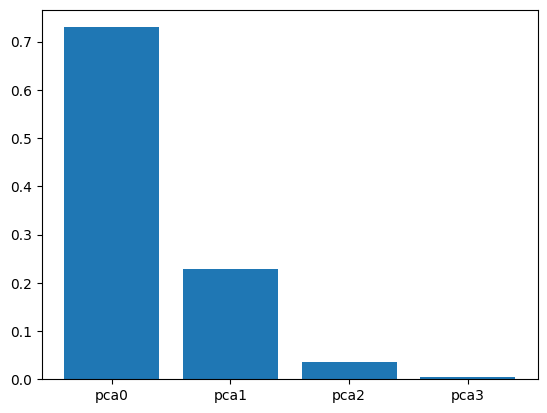

In [106]:
plt.bar(x_names, pca.explained_variance_ratio_)

In [107]:
import numpy as np

In [108]:
cumuputiv_variance = np.cumsum(pca.explained_variance_ratio_)

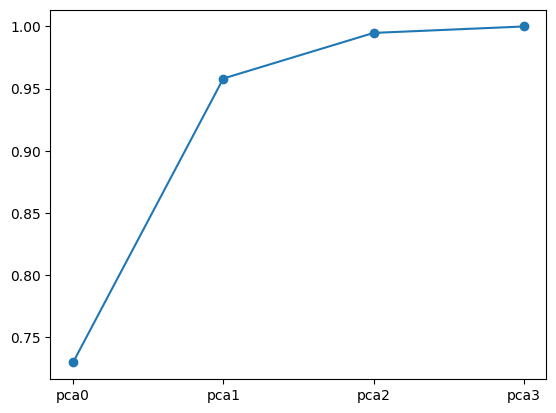

In [109]:
plt.plot(x_names, cumuputiv_variance, marker='o')

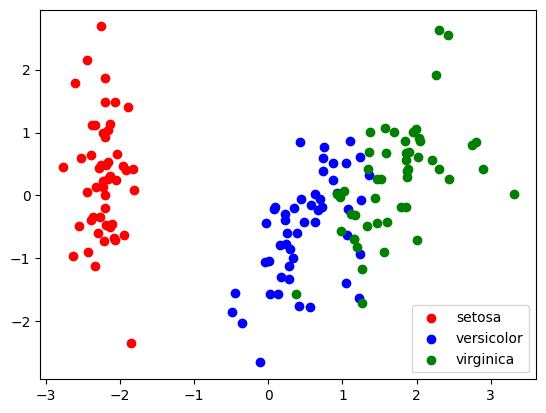

In [110]:
class_names = y.unique()
colors = ['red','blue','green']

for i, class_name in enumerate(class_names):
    class_instance =  x_pca.iloc[y[y == class_name].index]
    plt.scatter(class_instance['pca0'], class_instance['pca1'], color=colors[i], label=class_name)

plt.legend()

In [111]:
from sklearn.svm import SVC

In [112]:
from sklearn.model_selection import train_test_split, GridSearchCV

In [113]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [114]:
scaler = StandardScaler()

In [115]:
x_scaled = scaler.fit_transform(X_train)

In [116]:
X_train = pd.DataFrame(x_scaled, columns=X_train.columns)
X_train

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
0,-0.846320,0.691315,-1.160663,-0.906683
1,0.755936,-0.522533,1.073900,1.369588
2,-1.216071,0.205776,-1.217959,-1.308378
3,1.125688,0.205776,0.386342,0.298402
4,-0.846320,0.934085,-1.275256,-1.308378
...,...,...,...,...
100,-0.230068,-0.036993,0.214453,0.164504
101,1.125688,0.691315,1.131196,1.235690
102,0.879187,-0.036993,1.188493,1.369588
103,0.879187,0.448546,0.787417,1.101792


In [117]:
params = [{'C':  [2**i for i in range(-3,3)], 'kernel': ['linear'] }
          ,{'C': [2**i for i in range(-3,3)], 'kernel': ['poly'], 'gamma': np.arange(0,1,0.1)}]

In [118]:
grid = GridSearchCV(SVC(),params, cv=5, scoring='accuracy', verbose=4)

In [119]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 66 candidates, totalling 330 fits
[CV 1/5] END ............C=0.125, kernel=linear;, score=0.952 total time=   0.0s
[CV 2/5] END ............C=0.125, kernel=linear;, score=0.952 total time=   0.0s
[CV 3/5] END ............C=0.125, kernel=linear;, score=1.000 total time=   0.0s
[CV 4/5] END ............C=0.125, kernel=linear;, score=0.952 total time=   0.0s
[CV 5/5] END ............C=0.125, kernel=linear;, score=0.952 total time=   0.0s
[CV 1/5] END .............C=0.25, kernel=linear;, score=1.000 total time=   0.0s
[CV 2/5] END .............C=0.25, kernel=linear;, score=0.905 total time=   0.0s
[CV 3/5] END .............C=0.25, kernel=linear;, score=1.000 total time=   0.0s
[CV 4/5] END .............C=0.25, kernel=linear;, score=0.952 total time=   0.0s
[CV 5/5] END .............C=0.25, kernel=linear;, score=0.952 total time=   0.0s
[CV 1/5] END ..............C=0.5, kernel=linear;, score=1.000 total time=   0.0s
[CV 2/5] END ..............C=0.5, kernel=linear

,estimator,SVC()
,param_grid,"[{'C': [0.125, 0.25, ...], 'kernel': ['linear']}, {'C': [0.125, 0.25, ...], 'gamma': array([0. , 0....7, 0.8, 0.9]), 'kernel': ['poly']}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,4
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.5


In [120]:
grid.best_estimator_

,C,0.5
,kernel,'poly'
,degree,3
,gamma,np.float64(0.8)
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [121]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [122]:
X_test = scaler.transform(X_test)

In [123]:
y_test_predict = grid.best_estimator_.predict(X_test)

D:\ip1 vezbe\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [124]:
accuracy_score(y_test, y_test_predict)

0.9111111111111111

In [125]:
y_train_predict = grid.best_estimator_.predict(X_train)

In [126]:
accuracy_score(y_train, y_train_predict)

0.9809523809523809

In [127]:
confusion_matrix(y_test, y_test_predict)

array([[15,  0,  0],
       [ 0, 15,  0],
       [ 0,  4, 11]])